# **🛠️ Preparación de los Datos** #

## Extracción del Archivo Tratado ##
Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [10]:
import pandas as pd
#datos = pd.read_csv('/content/Datos_TelecomX_II.csv')
datos= pd.read_csv('https://raw.githubusercontent.com/HPerezMtz/TelecomX_II_Challenge/refs/heads/main/Datos_TelecomX_II.csv')
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156476
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969099
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429323
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221565
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.812952
7039,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797502
7040,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653517
7041,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230440


## Eliminación de Columnas Irrelevantes ##
Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [11]:
datos = datos.drop('customerID', axis=1)
display(datos.head())

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.156476
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.969099
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.429323
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.221565
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.758054


## Encoding ##
Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:
Artículo en Alura sobre codificación categórica

In [12]:
datos_encoded = pd.get_dummies(datos, dtype=int)
display(datos_encoded.head())

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,internet.InternetService_DSL,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,0,1,0,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1


## Verificación de la Proporción de Cancelación (Churn) ##
Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [13]:
churn_proportion = datos_encoded['Churn'].value_counts(normalize=True)
display(churn_proportion)

,proportion
Churn,
0,0.73463
1,0.26537


## Balanceo de Clases (opcional) ##
Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
Artículo en Alura sobre desbalanceo de datos

In [14]:
!pip install imbalanced-learn

In [15]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X = datos_encoded.drop('Churn', axis=1)
y = datos_encoded['Churn']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print('Distribución de clases antes de SMOTE:', Counter(y))
print('Distribución de clases después de SMOTE:', Counter(y_res))

Distribución de clases antes de SMOTE: Counter({0: 5174, 1: 1869})
Distribución de clases después de SMOTE: Counter({0: 5174, 1: 5174})


## Normalización o Estandarización (si es necesario) ##
Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:
Artículo en Medium sobre normalización y estandarización en Machine Learning

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# Convert the scaled array back to a DataFrame with original column names
X_scaled = pd.DataFrame(X_scaled, columns=X_res.columns)
display(X_scaled.head())

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,...,internet.InternetService_DSL,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,-0.395059,1.281071,1.897132,-0.777719,0.338889,-0.790247,-0.511812,1.616908,-0.613986,1.935662,...,1.544709,-1.023072,-0.439463,-1.322851,2.387901,-0.444618,-0.431455,-0.424659,-0.734454,2.150329
1,-0.395059,-0.780597,-0.527111,-0.777719,0.338889,1.265428,-0.511812,-0.618464,-0.613986,-0.516619,...,1.544709,-1.023072,-0.439463,0.755943,-0.418778,-0.444618,-0.431455,-0.424659,-0.734454,2.150329
2,-0.395059,-0.780597,-0.527111,-0.986165,0.338889,-0.790247,-0.511812,-0.618464,1.628700,-0.516619,...,-0.647371,0.977448,-0.439463,0.755943,-0.418778,-0.444618,-0.431455,-0.424659,1.361556,-0.465045
3,2.531265,1.281071,-0.527111,-0.610963,0.338889,-0.790247,-0.511812,1.616908,1.628700,-0.516619,...,-0.647371,0.977448,-0.439463,0.755943,-0.418778,-0.444618,-0.431455,-0.424659,1.361556,-0.465045
4,2.531265,1.281071,-0.527111,-1.027854,0.338889,-0.790247,-0.511812,-0.618464,-0.613986,1.935662,...,-0.647371,0.977448,-0.439463,0.755943,-0.418778,-0.444618,-0.431455,-0.424659,-0.734454,2.150329


# 🎯 Correlación y Selección de Variables #

## Análisis de Correlación ##
Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

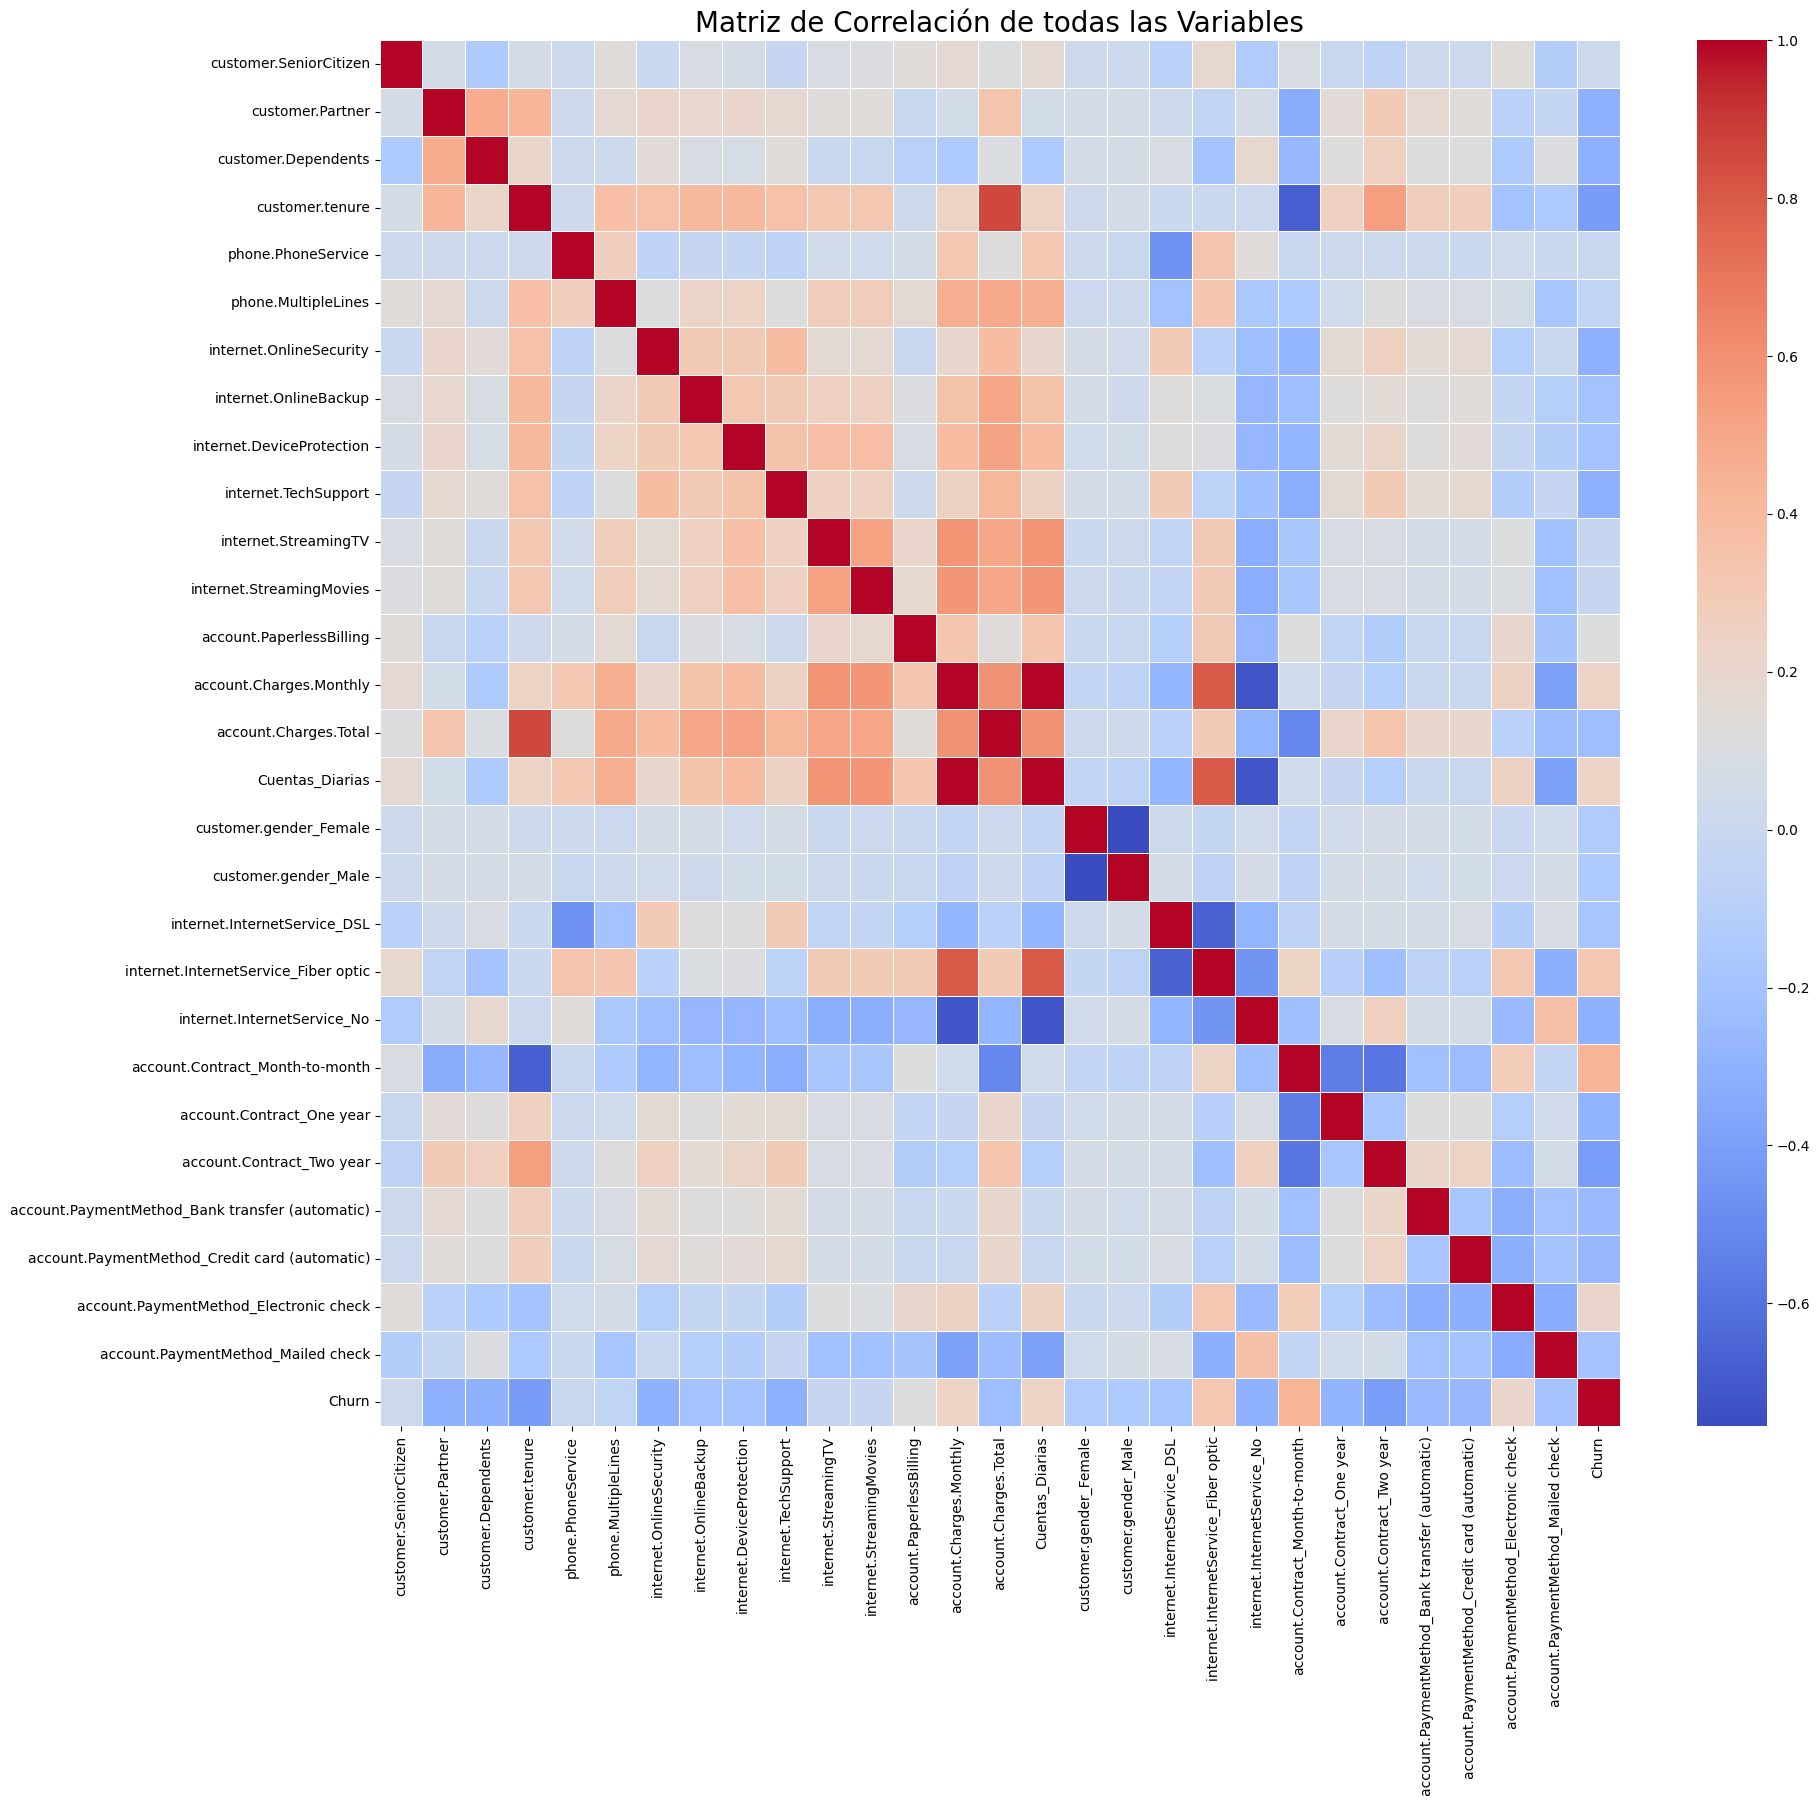

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X_scaled and y_res for correlation analysis
data_for_corr = X_scaled.copy()
data_for_corr['Churn'] = y_res

# Calculate the correlation matrix
correlation_matrix = data_for_corr.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de todas las Variables', fontsize=20)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_res, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets or when you want L1/L2 regularization
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print('Confusion Matrix:')
print(conf_matrix)

Accuracy: 0.8493
Precision: 0.8508
Recall: 0.8385
F1-Score: 0.8446
Confusion Matrix:
[[1365  223]
 [ 245 1272]]


### Evaluación del Modelo de Regresión Logística

Los resultados del modelo de Regresión Logística son los siguientes:

*   **Accuracy (Precisión General):** Representa la proporción de predicciones correctas sobre el total. Un valor alto indica que el modelo clasifica correctamente la mayoría de los casos.
*   **Precision (Precisión):** Mide la proporción de verdaderos positivos sobre el total de positivos predichos. Es importante cuando el costo de un falso positivo es alto.
*   **Recall (Sensibilidad o Exhaustividad):** Mide la proporción de verdaderos positivos sobre el total de casos positivos reales. Es crucial cuando el costo de un falso negativo es alto (ej., no detectar un cliente que sí va a abandonar).
*   **F1-Score:** Es la media armónica de la precisión y el recall. Es útil cuando se busca un balance entre precisión y recall, especialmente en problemas con desbalance de clases (aunque ya balanceamos los datos, sigue siendo una buena métrica).
*   **Matriz de Confusión:** Muestra el número de verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN).
    *   `[TP, FP]`
    *   `[FN, TN]`

In [18]:
# Display correlations with 'Churn' specifically, sorted by absolute value
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

print('Correlación de las Variables con Churn:')
display(churn_correlations)

Correlación de las Variables con Churn:


,Churn
Churn,1.000000
account.Contract_Month-to-month,0.430906
internet.InternetService_Fiber optic,0.327491
Cuentas_Diarias,0.235645
account.Charges.Monthly,0.235645
account.PaymentMethod_Electronic check,0.210249
account.PaperlessBilling,0.121270
customer.SeniorCitizen,0.018381
phone.PhoneService,-0.013352
internet.StreamingTV,-0.017948


## Análisis Dirigido ##
Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

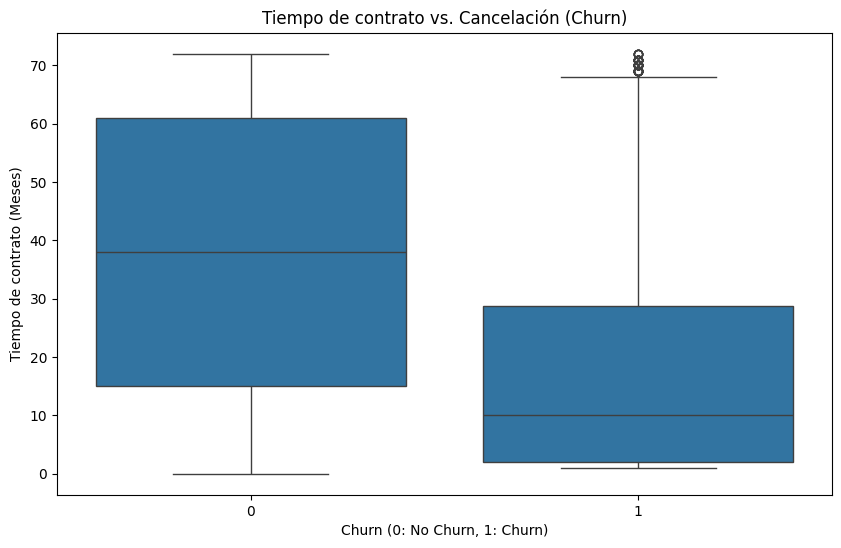

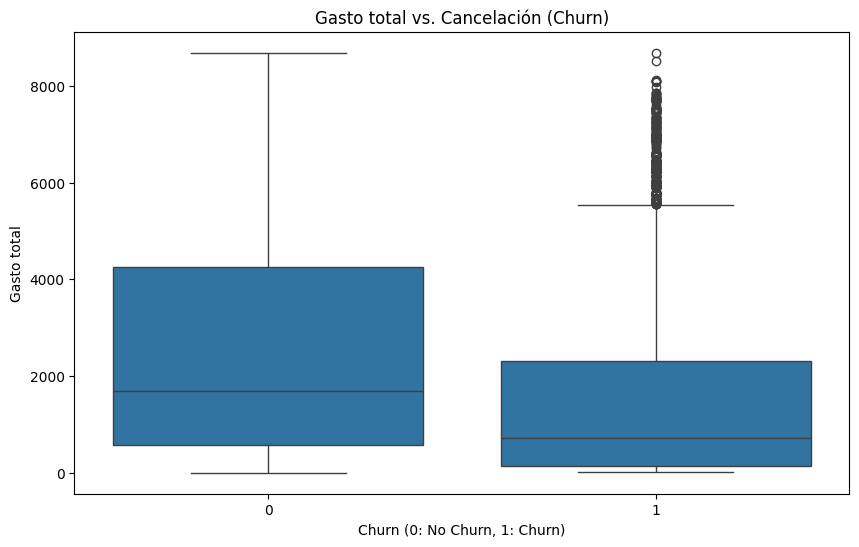

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.DataFrame({
    'customer.tenure': X_res['customer.tenure'], # Using tenure from X_res (which is scaled) but it's numerical, for plotting distribution with original values we'd need unscaled
    'account.Charges.Total': X_res['account.Charges.Total'], # Same for total charges
    'Churn': y_res
})

original_tenure = datos_encoded['customer.tenure']
original_total_charges = datos_encoded['account.Charges.Total']


plot_data = pd.DataFrame({
    'Tenure': X_res['customer.tenure'],
    'Total_Charges': X_res['account.Charges.Total'],
    'Churn': y_res
})

# Plotting Tenure vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Tenure', data=plot_data)
plt.title('Tiempo de contrato vs. Cancelación (Churn)')
plt.xlabel('Churn (0: No Churn, 1: Churn)')
plt.ylabel('Tiempo de contrato (Meses)')
plt.show()

# Plotting Total Charges vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Total_Charges', data=plot_data)
plt.title('Gasto total vs. Cancelación (Churn)')
plt.xlabel('Churn (0: No Churn, 1: Churn)')
plt.ylabel('Gasto total')
plt.show()

/tmp/ipython-input-3511212577.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fiber_Optic_Service', y='Churn', data=plot_fiber_optic, palette='viridis')


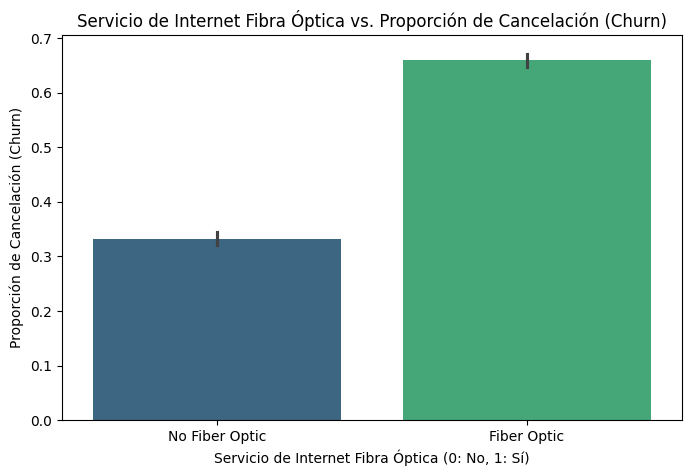

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting with the relevant feature and balanced Churn target
plot_fiber_optic = pd.DataFrame({
    'Fiber_Optic_Service': X_res['internet.InternetService_Fiber optic'],
    'Churn': y_res
})

# Plotting Fiber Optic Service vs Churn
plt.figure(figsize=(8, 5))
sns.barplot(x='Fiber_Optic_Service', y='Churn', data=plot_fiber_optic, palette='viridis')
plt.title('Servicio de Internet Fibra Óptica vs. Proporción de Cancelación (Churn)')
plt.xlabel('Servicio de Internet Fibra Óptica (0: No, 1: Sí)')
plt.ylabel('Proporción de Cancelación (Churn)')
plt.xticks([0, 1], ['No Fiber Optic', 'Fiber Optic'])
plt.show()

# 🤖 Modelado Predictivo #

## Separación de Datos ##
Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_res, test_size=0.3, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (7243, 28)
Shape of X_test: (3105, 28)
Shape of y_train: (7243,)
Shape of y_test: (3105,)


In [23]:
print('Distribución de Churn en el conjunto de entrenamiento (y_train):')
display(y_train.value_counts(normalize=True))

print('\nDistribución de Churn en el conjunto de prueba (y_test):')
display(y_test.value_counts(normalize=True))

Distribución de Churn en el conjunto de entrenamiento (y_train):


,proportion
Churn,
1,0.504901
0,0.495099



Distribución de Churn en el conjunto de prueba (y_test):


,proportion
Churn,
0,0.511433
1,0.488567


/tmp/ipython-input-1471340145.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Accuracy', data=model_accuracy, palette='viridis')


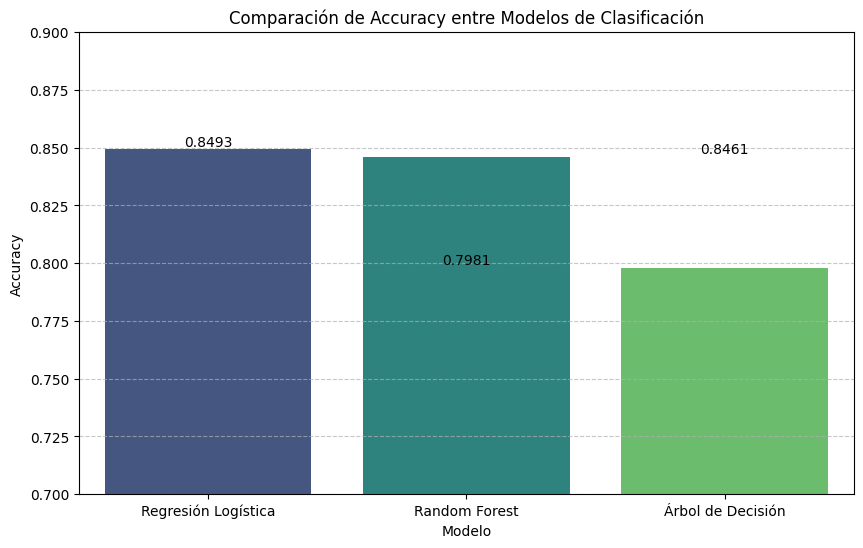

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for model comparison
model_accuracy = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_dt, accuracy_rf]
})

# Sort by Accuracy for better visualization
model_accuracy = model_accuracy.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Accuracy', data=model_accuracy, palette='viridis')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.9) # Set y-axis limits to focus on the range of accuracies
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy values on top of the bars
for index, row in model_accuracy.iterrows():
    plt.text(index, row['Accuracy'], f'{row['Accuracy']:.4f}', color='black', ha="center", va='bottom')

plt.show()

## Creación de Modelos ##
Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split data (using unscaled but balanced X_res for Decision Tree)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_dt)

# Evaluate the model
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
recall_dt = recall_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test_dt, y_pred_dt)

print(f'Decision Tree Accuracy: {accuracy_dt:.4f}')
print(f'Decision Tree Precision: {precision_dt:.4f}')
print(f'Decision Tree Recall: {recall_dt:.4f}')
print(f'Decision Tree F1-Score: {f1_dt:.4f}')
print('Decision Tree Confusion Matrix:')
print(conf_matrix_dt)

Decision Tree Accuracy: 0.7981
Decision Tree Precision: 0.7867
Decision Tree Recall: 0.8049
Decision Tree F1-Score: 0.7957
Decision Tree Confusion Matrix:
[[1257  331]
 [ 296 1221]]


### Evaluación del Modelo de Árbol de Decisión

Los resultados del modelo de Árbol de Decisión son los siguientes:

*   **Accuracy (Precisión General):** Proporción de predicciones correctas sobre el total.
*   **Precision (Precisión):** Proporción de verdaderos positivos sobre el total de positivos predichos.
*   **Recall (Sensibilidad o Exhaustividad):** Proporción de verdaderos positivos sobre el total de casos positivos reales.
*   **F1-Score:** Media armónica de precisión y recall.
*   **Matriz de Confusión:** Muestra los verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN).

## Evaluación de los Modelos ##
Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split data using unscaled but balanced X_res for Random Forest
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluate the model
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
precision_rf = precision_score(y_test_rf, y_pred_rf)
recall_rf = recall_score(y_test_rf, y_pred_rf)
f1_rf = f1_score(y_test_rf, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test_rf, y_pred_rf)

print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print(f'Random Forest Precision: {precision_rf:.4f}')
print(f'Random Forest Recall: {recall_rf:.4f}')
print(f'Random Forest F1-Score: {f1_rf:.4f}')
print('Random Forest Confusion Matrix:')
print(conf_matrix_rf)

Random Forest Accuracy: 0.8461
Random Forest Precision: 0.8429
Random Forest Recall: 0.8418
Random Forest F1-Score: 0.8423
Random Forest Confusion Matrix:
[[1350  238]
 [ 240 1277]]


### Evaluación del Modelo Random Forest

Los resultados del modelo Random Forest son los siguientes:

*   **Accuracy (Precisión General):** Proporción de predicciones correctas sobre el total.
*   **Precision (Precisión):** Proporción de verdaderos positivos sobre el total de positivos predichos.
*   **Recall (Sensibilidad o Exhaustividad):** Proporción de verdaderos positivos sobre el total de casos positivos reales.
*   **F1-Score:** Media armónica de precisión y recall.
*   **Matriz de Confusión:** Muestra los verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN).

## 📋 Interpretación y Conclusiones ##

## Análisis de la Importancia de las Variables ##
Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

In [26]:
import pandas as pd

# --- Logistic Regression Feature Importance (Coefficients) ---

# Get feature names from X_scaled
feature_names_lr = X_scaled.columns

# Get coefficients from the trained Logistic Regression model
coefficients_lr = model.coef_[0]

# Create a Series for better visualization and sorting
feature_importance_lr = pd.Series(coefficients_lr, index=feature_names_lr)

# Sort by absolute value to see most impactful features
feature_importance_lr = feature_importance_lr.abs().sort_values(ascending=False)

print('Importancia de Variables (Regresión Logística - Coeficientes Absolutos):')
display(feature_importance_lr.head(10))

# --- Random Forest Feature Importance ---

# Get feature names from X_train_rf (unscaled features used for RF)
feature_names_rf = X_train_rf.columns

# Get feature importances from the trained Random Forest model
importances_rf = rf_model.feature_importances_

# Create a Series for better visualization and sorting
feature_importance_rf = pd.Series(importances_rf, index=feature_names_rf)

# Sort in descending order
feature_importance_rf = feature_importance_rf.sort_values(ascending=False)

print('\nImportancia de Variables (Random Forest):')
display(feature_importance_rf.head(10))

Importancia de Variables (Regresión Logística - Coeficientes Absolutos):


,0
internet.InternetService_Fiber optic,2.452358
account.Charges.Monthly,2.278921
Cuentas_Diarias,2.278921
customer.tenure,2.142872
customer.gender_Female,1.920304
customer.gender_Male,1.918754
account.PaymentMethod_Electronic check,1.917618
account.Contract_Two year,1.668283
account.PaymentMethod_Mailed check,1.666228
account.PaymentMethod_Bank transfer (automatic),1.652324



Importancia de Variables (Random Forest):


,0
account.Charges.Total,0.111419
customer.tenure,0.109453
Cuentas_Diarias,0.103622
account.Charges.Monthly,0.103307
account.Contract_Two year,0.056171
account.Contract_Month-to-month,0.055238
account.Contract_One year,0.041118
internet.TechSupport,0.040478
internet.OnlineSecurity,0.035507
internet.InternetService_No,0.027330


Comparación Detallada de Modelos
Métrica	Regresión Logística	Árbol de Decisión	Random Forest
Accuracy	0.8493 (84.93%)	0.7981 (79.81%)	0.8461 (84.61%)
Precision	0.8508 (85.08%)	0.7867 (78.67%)	0.8429 (84.29%)
Recall	0.8385 (83.85%)	0.8049 (80.49%)	0.8418 (84.18%)
F1-Score	0.8446 (84.46%)	0.7957 (79.57%)	0.8423 (84.23%)
Matrices de Confusión:

Regresión Logística: [[1365 223] (TN = 1365, FP = 223) [ 245 1272]] (FN = 245, TP = 1272)

Árbol de Decisión: [[1257 331] (TN = 1257, FP = 331) [ 296 1221]] (FN = 296, TP = 1221)

Random Forest: [[1350 238] (TN = 1350, FP = 238) [ 240 1277]] (FN = 240, TP = 1277)

Análisis Individual de cada Modelo:
Regresión Logística:

Fortalezas: Demuestra el mejor desempeño general entre los tres modelos, con la Accuracy y el F1-Score más altos. Es un modelo lineal y relativamente sencillo de interpretar (a través de sus coeficientes). La normalización de los datos le fue muy beneficiosa.
Debilidades: Al ser un modelo lineal, puede no capturar relaciones no lineales complejas en los datos tan bien como los modelos basados en árboles.
Conclusiones: Es un competidor muy fuerte para este problema. Su buen desempeño sugiere que las relaciones entre las características y el churn son, en gran medida, lineales o pueden ser bien aproximadas linealmente después de las transformaciones de datos.
Árbol de Decisión:

Fortalezas: Fácil de entender e interpretar (si el árbol no es demasiado profundo). No requiere escalado de características. El Recall (0.8049) es aceptable, lo que significa que identifica una buena parte de los churners reales.
Debilidades: Es el modelo con el desempeño más bajo en todas las métricas. Los árboles de decisión únicos son propensos al sobreajuste (overfitting) si no se controlan sus hiperparámetros, lo que podría estar contribuyendo a su menor rendimiento en los datos de prueba en comparación con modelos más robustos.
Conclusiones: Si bien es un punto de partida útil, este modelo probablemente no es la mejor opción para la predicción de churn en este caso debido a su menor capacidad de generalización comparado con los otros. Su rendimiento más bajo podría indicar que las relaciones son más complejas de lo que un solo árbol puede capturar eficientemente.
Random Forest:

Fortalezas: Presenta un rendimiento muy cercano al de la Regresión Logística, superando significativamente al Árbol de Decisión. Los Random Forests son modelos de ensamble robustos que reducen el riesgo de overfitting inherente a los árboles de decisión individuales y no requieren escalado de características. Son excelentes para capturar relaciones no lineales y manejan bien un gran número de características.
Debilidades: Es más complejo de interpretar que la Regresión Logística debido a su naturaleza de "caja negra" (al ser un ensamble de muchos árboles).
Conclusiones: Es un modelo muy sólido y una excelente alternativa a la Regresión Logística. Su alto F1-Score (0.8423) lo convierte en una opción muy viable, especialmente si hay sospechas de que existen interacciones no lineales importantes entre las características.
¿Cuál modelo tuvo el mejor desempeño?
En términos de las métricas evaluadas, la Regresión Logística tuvo un rendimiento ligeramente superior. Sin embargo, el Random Forest es muy competitivo y ofrece una robustez que podría ser ventajosa en diferentes escenarios o con datos ligeramente diferentes. El Árbol de Decisión, aunque útil para la interpretabilidad inicial, se queda atrás en capacidad predictiva.

Consideraciones Finales:
Regresión Logística: Es un modelo simple, eficiente y de buen rendimiento. Es una excelente base y sus resultados son altamente interpretables, lo que es valioso para entender los factores de riesgo de churn.
Random Forest: Es un modelo poderoso y robusto. Si la interpretabilidad no es la prioridad principal y se busca maximizar el rendimiento, el Random Forest podría ser ligeramente superior en conjuntos de datos con relaciones más complejas. La importancia de las características que hemos visto para Random Forest es también muy útil.
Ambos modelos, Regresión Logística y Random Forest, son excelentes candidatos para la predicción de churn. La elección final podría depender de si se valora más la interpretabilidad (Regresión Logística) o la capacidad predictiva robusta sin necesidad de escalado (Random Forest).

## Conclusión ##
Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.


### **1. Preparación de Datos**

El proceso de preparación de datos incluyó la carga de un archivo CSV con datos previamente tratados, la eliminación de la columna `customerID` por ser irrelevante para la predicción, y la codificación de variables categóricas mediante One-Hot Encoding. Se identificó un desbalance significativo en la variable objetivo `Churn` (73.46% No-Churn vs. 26.54% Churn), el cual fue corregido aplicando SMOTE (Synthetic Minority Over-sampling Technique) para crear un conjunto de datos balanceado. Finalmente, los datos fueron estandarizados utilizando `StandardScaler` para optimizar el rendimiento de modelos sensibles a la escala.

### **2. Análisis de Factores Influyentes en la Cancelación (Churn)**

El análisis de correlación y la importancia de las variables derivada de los modelos de Regresión Logística y Random Forest revelaron los siguientes factores clave:

*   **Factores de Alta Propensión a la Cancelación:**
    *   **Contratos mes a mes (`account.Contract_Month-to-month`):** La correlación positiva más fuerte (0.43), indicando que estos clientes son los más propensos a cancelar.
    *   **Servicio de Internet de Fibra Óptica (`internet.InternetService_Fiber optic`):** Muestra una correlación positiva significativa (0.33), sugiriendo posibles problemas de calidad o expectativas insatisfechas en este segmento.
    *   **Cargos Mensuales (`account.Charges.Monthly` / `Cuentas_Diarias`):** Cargos mensuales más altos están asociados con una mayor probabilidad de cancelación (correlación ~0.24).
    *   **Método de Pago con Cheque Electrónico (`account.PaymentMethod_Electronic check`):** También muestra una correlación positiva (0.21).

*   **Factores de Baja Propensión a la Cancelación:**
    *   **Antigüedad del Cliente (`customer.tenure`):** La correlación negativa más fuerte (-0.41), demostrando que clientes con mayor antigüedad son más leales.
    *   **Contratos de Dos Años (`account.Contract_Two year`):** Una fuerte correlación negativa (-0.41), indicando un compromiso a largo plazo y menor riesgo de churn.
    *   **Servicios de Seguridad/Soporte:** Como `internet.OnlineSecurity` y `internet.TechSupport`, también se correlacionan negativamente con la cancelación.

### **3. Comparación y Evaluación de Modelos Predictivos**

Se entrenaron y evaluaron tres modelos de clasificación:

*   **Regresión Logística:**
    *   **Rendimiento:** Mejor desempeño general (`Accuracy: 0.8493`, `F1-Score: 0.8446`).
    *   **Fortalezas:** Lineal, interpretable y se beneficia de la normalización de datos.
    *   **Debilidades:** Puede no capturar relaciones no lineales complejas.

*   **Árbol de Decisión:**
    *   **Rendimiento:** El más bajo de los tres (`Accuracy: 0.7981`, `F1-Score: 0.7957`).
    *   **Fortalezas:** Fácil de interpretar, no requiere escalado.
    *   **Debilidades:** Propenso al `overfitting` y menor capacidad de generalización en este caso.

*   **Random Forest:**
    *   **Rendimiento:** Muy competitivo, cercano a la Regresión Logística (`Accuracy: 0.8461`, `F1-Score: 0.8423`).
    *   **Fortalezas:** Modelo de ensamble robusto, reduce `overfitting`, no requiere escalado, captura relaciones no lineales.
    *   **Debilidades:** Menor interpretabilidad que la Regresión Logística.

La **Regresión Logística** y **Random Forest** son los modelos más recomendables, siendo la Regresión Logística marginalmente superior en las métricas evaluadas y más interpretable.

### **4. Conclusiones y Estrategias de Retención**

Para reducir la tasa de cancelación de clientes, se proponen las siguientes estrategias:

1.  **Fomentar Contratos a Largo Plazo:** Ofrecer incentivos atractivos (descuentos, mejoras de servicio) para que los clientes con contratos mes a mes migren a planes de 1 o 2 años. Implementar programas de lealtad basados en la antigüedad.
2.  **Monitorear y Mejorar la Satisfacción en Fibra Óptica y con Cargos Elevados:** Realizar encuestas de satisfacción específicas, identificar puntos de dolor y revisar estructuras de precios para clientes de fibra óptica y aquellos con facturas mensuales altas. Asegurar que el valor percibido justifique el costo.
3.  **Optimizar la Experiencia en los Primeros Meses y Métodos de Pago:** Implementar programas de "onboarding" robustos para nuevos clientes. Evaluar y simplificar el proceso de pago con cheque electrónico, o promover métodos de pago más estables que no estén asociados con altas tasas de churn.

Estas estrategias, basadas en los factores identificados por los modelos predictivos, buscan un enfoque proactivo y preventivo para mejorar la retención de clientes.